In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import math
import os
os.chdir('..')

In [ ]:
f2 = 'data/output/figures/'

In [3]:
estimatedMI_central = pd.read_csv('data/output/mutual_info/estimated_mutual_info_all_epitopes_w_studyspecific_shuffle_wdupl.csv')
estimatedMI_end = pd.read_csv('data/output/mutual_info/estimated_mutual_info_all_epitopes_endpadding_w_studyspecific_shuffle_wdupl.csv')

In [4]:
estimatedMI_central.columns = ['name', 'real', 'shuffle']

estimatedMI_central[['epitope', 'vars']] = estimatedMI_central['name'].str.split('_', 1, expand=True)
estimatedMI_central[['var1','var2']] = estimatedMI_central['vars'].str.split('-', 1, expand=True)
estimatedMI_central = estimatedMI_central.drop(['name','vars'], axis=1)
estimatedMI_central['real_MI'] = estimatedMI_central['real'] - estimatedMI_central['shuffle']
estimatedMI_central['var1'] = estimatedMI_central['var1'].replace('cdr3a','CDR3a')
estimatedMI_central['var2'] = estimatedMI_central['var2'].replace('cdr3a','CDR3a')
estimatedMI_central['var1'] = estimatedMI_central['var1'].replace('cdr3b','CDR3b')
estimatedMI_central['var2'] = estimatedMI_central['var2'].replace('cdr3b','CDR3b')
print(estimatedMI_central)

          real    shuffle     epitope   var1   var2   real_MI
0    15.700707   6.661307   ASNENMETM     Ja  CDR3a  9.039400
1     8.410085   5.266553   ASNENMETM     Ja  CDR3b  3.143532
2     0.838501   0.540358   ASNENMETM     Ja     Jb  0.298142
3     4.095908   2.620880   ASNENMETM     Jb  CDR3a  1.475028
4     9.929622   2.113542   ASNENMETM     Jb  CDR3b  7.816080
..         ...        ...         ...    ...    ...       ...
355   5.329278   4.466636  background     Vb  CDR3a  0.862643
356   7.339870   4.361322  background     Vb  CDR3b  2.978547
357   1.086592   0.900223  background     Vb     Ja  0.186369
358   0.477628   0.353073  background     Vb     Jb  0.124555
359  22.553455  19.697879  background  CDR3a  CDR3b  2.855576

[360 rows x 6 columns]


/var/folders/db/wdwm3pms6vzcb18_z1tmpjk5ngjqkh/T/ipykernel_40185/447558215.py:3: FutureWarning: In a future version of pandas all arguments of StringMethods.split except for the argument 'pat' will be keyword-only.
  estimatedMI_central[['epitope', 'vars']] = estimatedMI_central['name'].str.split('_', 1, expand=True)
/var/folders/db/wdwm3pms6vzcb18_z1tmpjk5ngjqkh/T/ipykernel_40185/447558215.py:4: FutureWarning: In a future version of pandas all arguments of StringMethods.split except for the argument 'pat' will be keyword-only.
  estimatedMI_central[['var1','var2']] = estimatedMI_central['vars'].str.split('-', 1, expand=True)


In [5]:
estimatedMI_end.columns = ['name', 'real', 'shuffle']

estimatedMI_end[['epitope', 'vars']] = estimatedMI_end['name'].str.split('_', 1, expand=True)
estimatedMI_end[['var1','var2']] = estimatedMI_end['vars'].str.split('-', 1, expand=True)
estimatedMI_end = estimatedMI_end.drop(['name','vars'], axis=1)
estimatedMI_end['real_MI'] = estimatedMI_end['real'] - estimatedMI_end['shuffle']
estimatedMI_end['var1'] = estimatedMI_end['var1'].replace('cdr3a','CDR3a')
estimatedMI_end['var2'] = estimatedMI_end['var2'].replace('cdr3a','CDR3a')
estimatedMI_end['var1'] = estimatedMI_end['var1'].replace('cdr3b','CDR3b')
estimatedMI_end['var2'] = estimatedMI_end['var2'].replace('cdr3b','CDR3b')
print(estimatedMI_end)

          real    shuffle     epitope   var1   var2   real_MI
0    15.711106   8.420703   ASNENMETM     Ja  CDR3a  7.290403
1    10.288075   6.506668   ASNENMETM     Ja  CDR3b  3.781407
2     0.795896   0.520775   ASNENMETM     Ja     Jb  0.275121
3     4.996568   3.113765   ASNENMETM     Jb  CDR3a  1.882803
4     9.249349   2.570179   ASNENMETM     Jb  CDR3b  6.679170
..         ...        ...         ...    ...    ...       ...
355   6.424274   5.548328  background     Vb  CDR3a  0.875946
356   8.641470   5.075547  background     Vb  CDR3b  3.565923
357   1.088194   0.909987  background     Vb     Ja  0.178206
358   0.480876   0.353636  background     Vb     Jb  0.127240
359  32.818407  28.866374  background  CDR3a  CDR3b  3.952034

[360 rows x 6 columns]


/var/folders/db/wdwm3pms6vzcb18_z1tmpjk5ngjqkh/T/ipykernel_40185/887623165.py:3: FutureWarning: In a future version of pandas all arguments of StringMethods.split except for the argument 'pat' will be keyword-only.
  estimatedMI_end[['epitope', 'vars']] = estimatedMI_end['name'].str.split('_', 1, expand=True)
/var/folders/db/wdwm3pms6vzcb18_z1tmpjk5ngjqkh/T/ipykernel_40185/887623165.py:4: FutureWarning: In a future version of pandas all arguments of StringMethods.split except for the argument 'pat' will be keyword-only.
  estimatedMI_end[['var1','var2']] = estimatedMI_end['vars'].str.split('-', 1, expand=True)


In [6]:
X = pd.merge(estimatedMI_central[['epitope','var1', 'var2', 'real_MI']], 
             estimatedMI_end[['epitope','var1', 'var2', 'real_MI']],
             on = ['epitope','var1', 'var2'])

9 [('Ja', 'CDR3a'), ('Ja', 'CDR3b'), ('Jb', 'CDR3a'), ('Jb', 'CDR3b'), ('Va', 'CDR3a'), ('Va', 'CDR3b'), ('Vb', 'CDR3a'), ('Vb', 'CDR3b'), ('CDR3a', 'CDR3b')]
Ja CDR3a
Ja CDR3b
Jb CDR3a
Jb CDR3b
Va CDR3a
Va CDR3b
Vb CDR3a
Vb CDR3b
CDR3a CDR3b


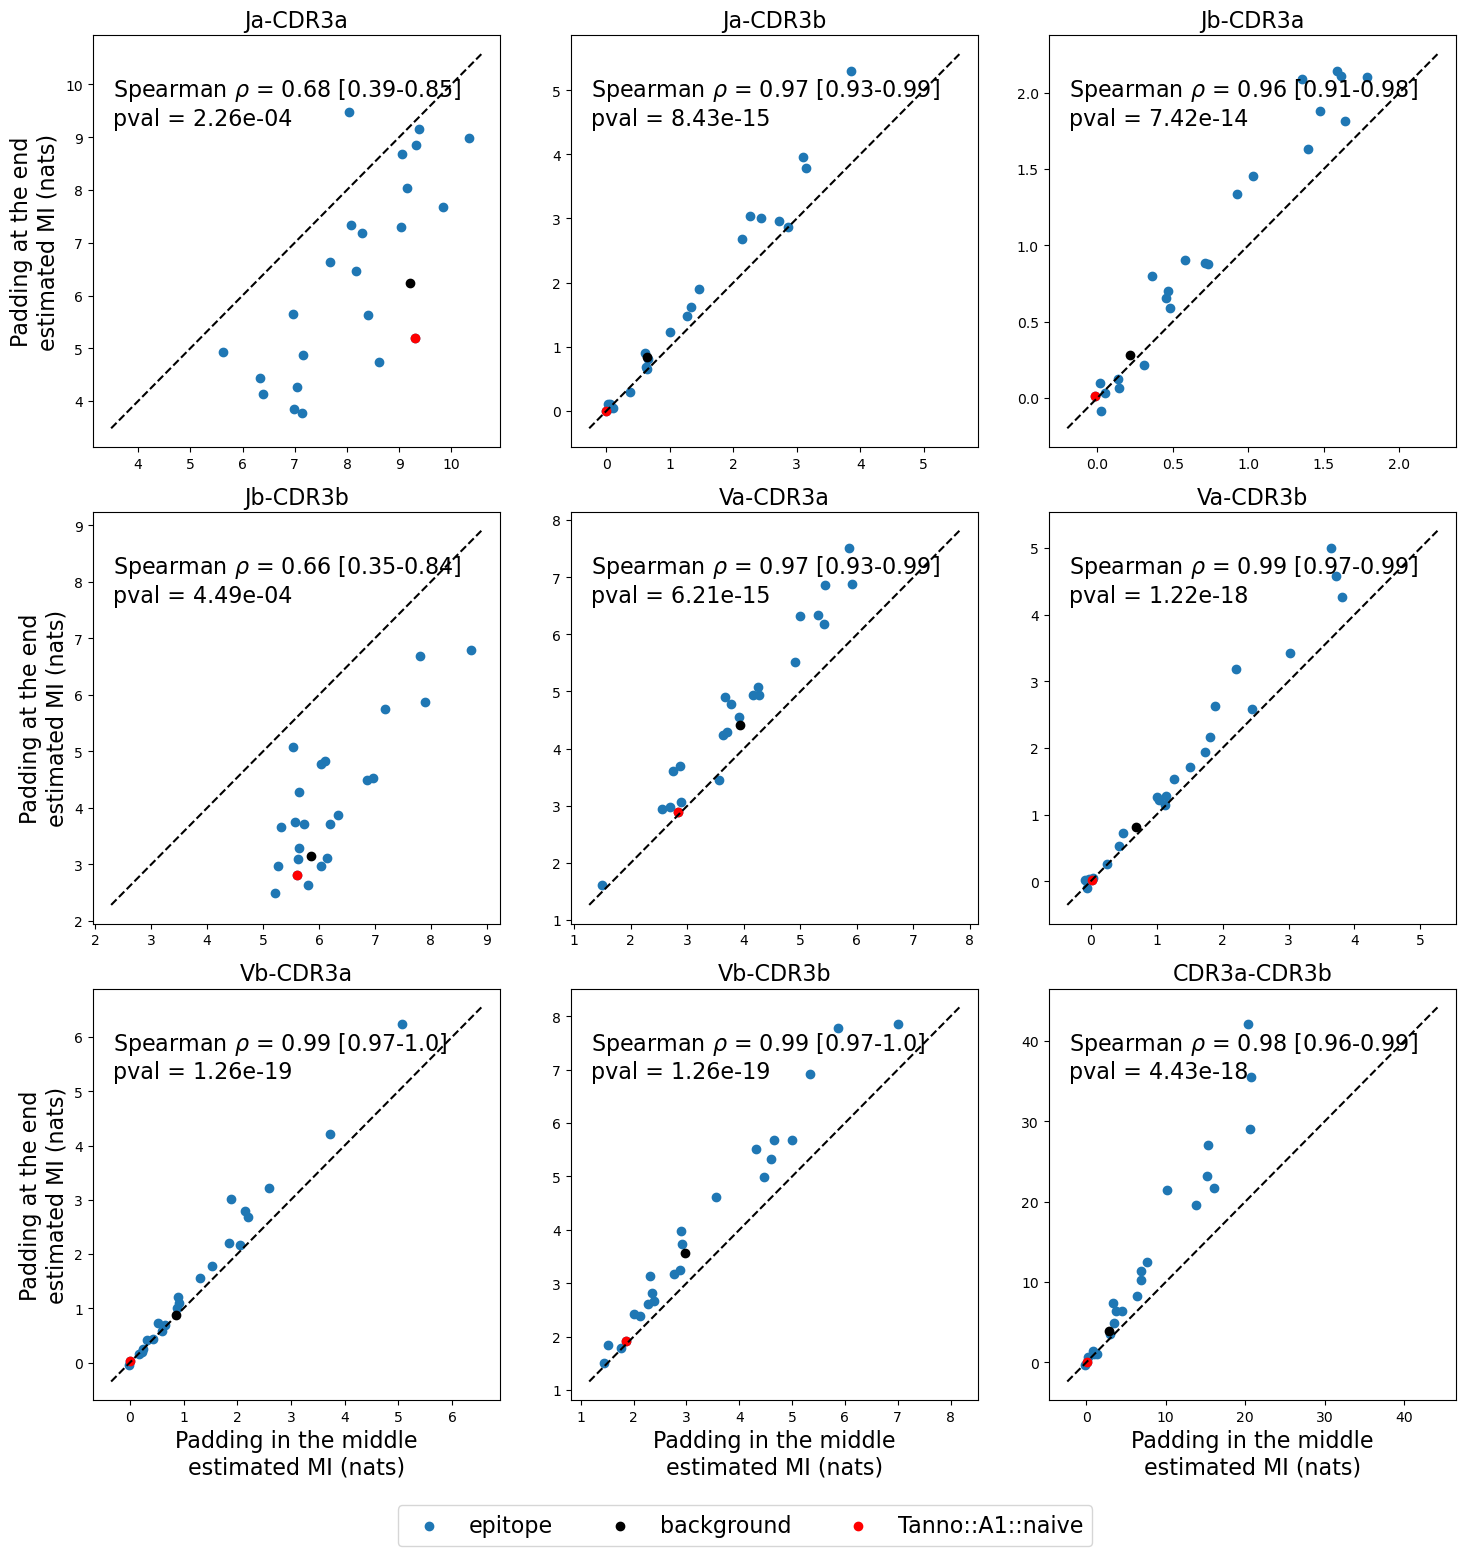

In [7]:
unique_pairs = X[['var1', 'var2']].drop_duplicates()
unique_pairs_cdr3 = unique_pairs.loc[unique_pairs['var1'].str.contains('CDR3') | unique_pairs['var2'].str.contains('CDR3')]
pairs = [(x, y) for x, y in zip(unique_pairs_cdr3['var1'], unique_pairs_cdr3['var2'])]
print(len(pairs), pairs)

f, axs = plt.subplots(ncols = 3, nrows = 3, figsize = (15, 15))
ax = axs.ravel()

for i, (v1, v2) in enumerate(pairs):
    print(v1, v2)
    ss = X.loc[(X['var1'] == v1) & (X['var2'] == v2)]
    x = ss['real_MI_x']
    y = ss['real_MI_y']
    R, p = spearmanr(x,y)
    
    # calculate CI
    count = len(x)
    stderr = 1.0 / math.sqrt(count - 3)
    delta = 1.96 * stderr
    lower = math.tanh(math.atanh(R) - delta)
    upper = math.tanh(math.atanh(R) + delta)

    # print(v1, v2, )
    ax[i].scatter(ss.loc[ss['epitope'] != 'background']['real_MI_x'], 
                  ss.loc[ss['epitope'] != 'background']['real_MI_y'], label = 'epitope')
    ax[i].scatter(ss.loc[ss['epitope'] == 'background']['real_MI_x'], 
                  ss.loc[ss['epitope'] == 'background']['real_MI_y'], 
                  c = 'k', label = 'background')
    ax[i].scatter(ss.loc[ss['epitope'] == 'Tanno::A1::naive']['real_MI_x'], 
                  ss.loc[ss['epitope'] == 'Tanno::A1::naive']['real_MI_y'], 
                  c = 'r', label = 'Tanno::A1::naive')

    xlim = ax[i].get_xlim()
    ylim = ax[i].get_ylim()
    ax[i].plot([min(xlim[0], ylim[0]),max(xlim[1], ylim[1])], [min(xlim[0], ylim[0]),max(xlim[1], ylim[1])], ls = '--', c = 'k')
    ax[i].set_title(v1 + '-' + v2, fontsize = 16)
    ax[i].text(0.05, 0.9, r'Spearman $\rho$ = ' + f'{round(R,2)} [{round(lower,2)}-{round(upper,2)}]' + '\npval = ' + '{:.2e}'.format(p), 
               transform=ax[i].transAxes,fontsize = 16, verticalalignment='top')

    if i in [0,3,6]:
        ax[i].set_ylabel('Padding at the end\nestimated MI (nats)', fontsize = 16)
    if i > 5:
        ax[i].set_xlabel('Padding in the middle\nestimated MI (nats)', fontsize = 16)

handles, l = ax[i].get_legend_handles_labels()
lgd = f.legend(handles, l, bbox_to_anchor = [0.5,0], loc='upper center', ncols = 3, fontsize = 16)
plt.tight_layout()
plt.savefig(f2 + 'MI_padding_comparison_w_studyspecific_shuffle_wdupl.png',
            bbox_extra_artists=(lgd,), bbox_inches='tight')
plt.show()

In [8]:
estimatedMI_central['epitope'].unique()

array(['ASNENMETM', 'ATDALMTGF', 'AVFDRKSDAK', 'CINGVCWTV', 'ELAGIGILTV',
       'GILGFVFTL', 'GLCTLVAML', 'HGIRNASFI', 'IVTDFSVIK', 'KSKRTPMGF',
       'LLWNGPMAV', 'LSLRNPILV', 'LTDEMIAQY', 'NLVPMVATV', 'RAKFKQLL',
       'RLRAEAQVK', 'SPRWYFYYL', 'SSLENFRAYV', 'SSPPMFRV', 'SSYRRPVGI',
       'TTDPSFLGRY', 'Tanno::A1::naive', 'YLQPRTFLL', 'background'],
      dtype=object)